Problem size Test

In [ ]:
import matplotlib.pyplot as plt
import os

# Create a directory to store figures
os.makedirs("figures", exist_ok=True)

# Counter for unique filenames
fig_counter = 0

def my_show(*args, **kwargs):
    global fig_counter
    # Create a filename based on the counter
    filename = os.path.join("figures", f"figure_{fig_counter}.png")
    plt.savefig(filename, bbox_inches="tight")
    plt.close()  # Optionally close the figure after saving
    print(f"Figure saved as {filename}")
    fig_counter += 1

# Override plt.show with our custom function
plt.show = my_show

In [ ]:
import simtool.simtool as simtool

Threads = [1,2,3,4,5,6, 7, 8, 9 , 10, 11,12,13,14,15,16,17,18,19,20] 

df_results = simtool.multithreading_test(Threads=Threads, presets=['intrinsics'])
print(df_results)

df_results.to_csv('multithreading_test.csv')



Building preset 'intrinsics' for L=1024 in directory /home/lfissore/Documents/Facultad/paralela2025/tiny_ising/out/intrinsics_1024_5 ...
{'compiler': 'gcc', 'optimization_flags': '-O3', 'L': 1024, 'metric': 56.97178, 'error': None, 'preset': 'intrinsics', 'Threads': 1, 'TRAN': 5}
Building preset 'intrinsics' for L=1024 in directory /home/lfissore/Documents/Facultad/paralela2025/tiny_ising/out/intrinsics_1024_5 ...
{'compiler': 'gcc', 'optimization_flags': '-O3', 'L': 1024, 'metric': 24.474489, 'error': None, 'preset': 'intrinsics', 'Threads': 2, 'TRAN': 5}
Building preset 'intrinsics' for L=1024 in directory /home/lfissore/Documents/Facultad/paralela2025/tiny_ising/out/intrinsics_1024_5 ...
{'compiler': 'gcc', 'optimization_flags': '-O3', 'L': 1024, 'metric': 19.929369, 'error': None, 'preset': 'intrinsics', 'Threads': 3, 'TRAN': 5}
Building preset 'intrinsics' for L=1024 in directory /home/lfissore/Documents/Facultad/paralela2025/tiny_ising/out/intrinsics_1024_5 ...
{'compiler': 'gcc'

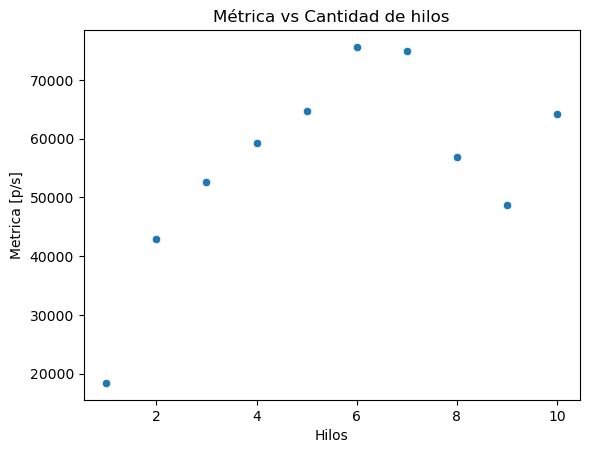

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

df = pd.read_csv('multithreading_test.csv')


# Use seaborn to create a line plot
sns.scatterplot(x='Threads', y='metric', data=df)

# Set the plot title and axis labels
plt.title('Métrica vs Cantidad de hilos')
plt.xlabel('Hilos')
plt.ylabel('Metrica [p/s]')
# plt.xticks(df.L.unique(), rotation=90)

# Show the plot
plt.show()

([<matplotlib.axis.XTick at 0x7606520634d0>,
 [Text(1, 0, '1'),
  Text(2, 0, '2'),
  Text(3, 0, '3'),
  Text(4, 0, '4'),
  Text(5, 0, '5'),
  Text(6, 0, '6'),
  Text(7, 0, '7'),
  Text(8, 0, '8'),
  Text(9, 0, '9'),
  Text(10, 0, '10')])

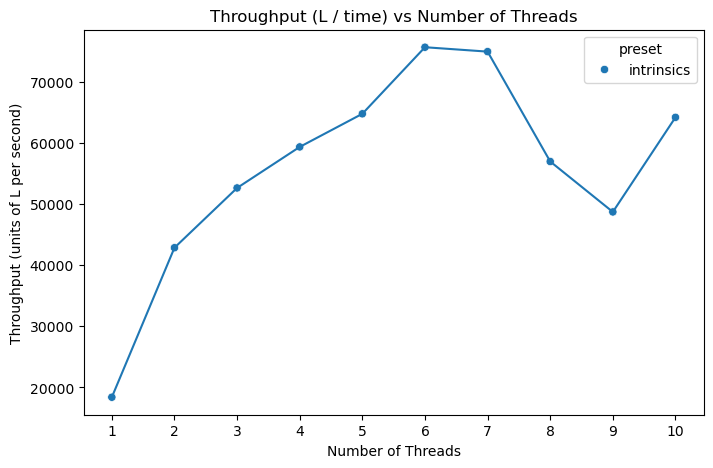

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# 1) Load the results
df = pd.read_csv('multithreading_test.csv')


# 2) Compute throughput = work done (L) divided by time (metric)
df['throughput'] = df['L'] * df['L'] / df['metric']

# 3) Plot
plt.figure(figsize=(8, 5))
sns.scatterplot(x='Threads', y='throughput', hue='preset', style='preset', data=df)
sns.lineplot   (x='Threads', y='throughput', hue='preset', style='preset', data=df, legend=False)

# 4) Labels and title
plt.title('Throughput (L / time) vs Number of Threads')
plt.xlabel('Number of Threads')
plt.ylabel('Throughput (units of L per second)')
plt.xticks(sorted(df['Threads'].unique()))

In [ ]:
import glob
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# 1) Read all CSVs, assume filenames like multithreading_L=1024.csv
dfs = []
for fn in glob.glob("multithreading_*.csv"):
    df = pd.read_csv(fn)
    # If your CSVs don’t already have an 'L' column,
    # parse it out of the filename:
    # e.g. 'multithreading_L=1024.csv' → 1024
    # L = int(fn.split("L=")[1].split(".csv")[0])
    # df["L"] = L
    dfs.append(df)

big = pd.concat(dfs, ignore_index=True)

# 2) Compute throughput
big["throughput"] = big["L"] / big["metric"]

# 3) Facet by L
g = sns.FacetGrid(big, col="L", col_wrap=3, sharey=False, height=4)
g.map_dataframe(sns.scatterplot, "Threads", "throughput", "preset")
g.map_dataframe(sns.lineplot,    "Threads", "throughput", "preset", legend=False)

g.set_axis_labels("Threads", "Throughput (L / time)")
g.add_legend()
plt.tight_layout()

IndexError: list index out of range

In [9]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

import numpy as np

def scale(arr):
    return np.divide(arr,L*L)

# note the double square brackets around the 'x'!!
# this is because we want to use DataFrame.apply,
# not Series.apply!!
df_metric = df_results
df_metric['metric'] = df[['metric']].apply(scale)


# Use seaborn to create a line plot
sns.scatterplot(x='L', y='metric', data=df_results)

# Set the plot title and axis labels
plt.title('Metric vs Grid Size')
plt.xlabel('Grid Size')
plt.ylabel('Time')
plt.xticks(df_results.L.unique(), rotation=90)

# Show the plot
plt.show()

NameError: name 'L' is not defined

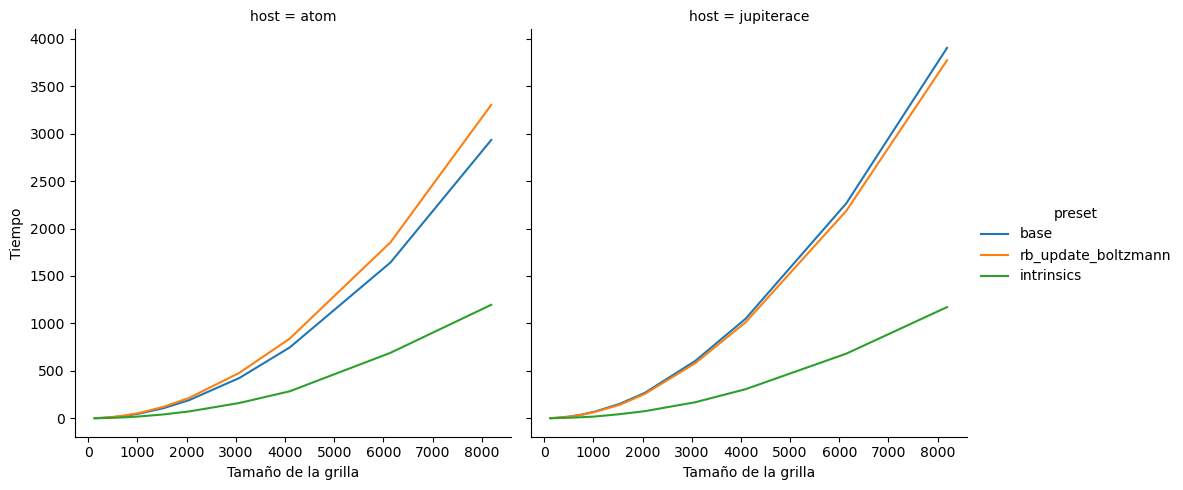

In [3]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

df = pd.read_csv('test_results/problem_size_test_lab2_atom.csv')
df['host'] = 'atom'

df2 = pd.read_csv('test_results/problem_size_test_lab2_jupiterace.csv')
df2['host'] = 'jupiterace'

df = pd.concat([df, df2])

df = df.rename(columns={"metric": "Tiempo", "L": "Tamaño de la grilla"})
# Use seaborn to create a line plot
sns.relplot(x='Tamaño de la grilla', y='Tiempo', data=df,kind="line", hue='preset', col='host')


# Set the plot title and axis labels
# plt.title('Tiempo vs Tamaño de la grilla')
# plt.xlabel('Tamaño de la grilla')
# plt.ylabel('Tiempo')
# plt.xticks(df.L.unique(), rotation=90)

# Show the plot
plt.show()